# 1 · Dataset Subsetting & Embedding Extraction

This notebook:
1. Loads the real **BSD10k** dataset from local `audio/` and `metadata/` folders
2. Inspects the taxonomy (23 second-level classes, 5 top-level classes)
3. Selects a **subset of classes** and saves a filtered metadata CSV
4. Extracts **MFCC**, **FSD-SINet**, and **CLAP** embeddings for every sound in the subset and saves them as `.npy` files

After running this notebook, `notebooks/2_sound_classification.ipynb` and
`notebooks/3_text_audio_retrieval.ipynb` can load the pre-computed embeddings directly.


## 0 · Paths & imports

In [1]:
import os, sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ── Edit these two lines to match where you placed the downloaded dataset ─────
AUDIO_FOLDER    = '../audio'       # root/audio/{sound_id}.wav
METADATA_FOLDER = '../metadata'    # root/metadata/BSD10k_metadata.csv  etc.
# ─────────────────────────────────────────────────────────────────────────────

# Where computed embeddings will be stored
EMBEDDINGS_FOLDER = '../embeddings'
os.makedirs(EMBEDDINGS_FOLDER, exist_ok=True)

# Where the filtered subset metadata CSV will be saved
SUBSET_CSV = '../metadata/subset_metadata.csv'

print(f'Audio folder  : {os.path.abspath(AUDIO_FOLDER)}')
print(f'Metadata      : {os.path.abspath(METADATA_FOLDER)}')
print(f'Embeddings out: {os.path.abspath(EMBEDDINGS_FOLDER)}')


Audio folder  : /home/frederic/Documents/UPF/semester3/advanced/block2_assignment/sound-classification-repo/audio
Metadata      : /home/frederic/Documents/UPF/semester3/advanced/block2_assignment/sound-classification-repo/metadata
Embeddings out: /home/frederic/Documents/UPF/semester3/advanced/block2_assignment/sound-classification-repo/embeddings


## 1 · Load and inspect metadata

The dataset ships with two CSVs inside `metadata/`:
- `BSD10k_metadata.csv` — one row per sound, columns: `sound_id`, `class`, `class_idx`, `class_top`, `title`, `tags`, `uploader`, `license`
- `BST_description.csv` — one row per class, includes the human-readable class name

Key point: `class` contains a **short code** (e.g. `"MUS"`, `"INS"`, `"SFX"`).
We join with `BST_description.csv` to get the full name.


In [2]:
metadata_df = pd.read_csv(os.path.join(METADATA_FOLDER, 'BSD10k_metadata.csv'))
bst_df      = pd.read_csv(os.path.join(METADATA_FOLDER, 'BST_description.csv'))

print(f'Total sounds : {len(metadata_df)}')
print(f'Columns      : {list(metadata_df.columns)}')
print()
display(metadata_df.head(3))
print()
print('BST description columns:', list(bst_df.columns))
display(bst_df.head(5))


Total sounds : 10309
Columns      : ['sound_id', 'class', 'class_idx', 'class_top', 'set', 'uploader', 'license', 'tags', 'title']



,sound_id,class,class_idx,class_top,set,uploader,license,tags,title
0,185755,fx-o,11,fx,train,marcgp13,http://creativecommons.org/licenses/by/3.0/,"campus-upf,UPF-CS13,microwave,heat,bell,noise",microwave_oven.wav
1,358405,is-w,5,is,train,MTG,http://creativecommons.org/licenses/by/3.0/,"good-sounds,single-note,multisample,sax,neuman...",Sax Alto - F5
2,358760,is-w,5,is,train,MTG,http://creativecommons.org/licenses/by/3.0/,"good-sounds,sax,neumann-U87,GsharpMajor,scale,...",Sax Alto - G# Major



BST description columns: ['ClassKey', 'TopLevel', 'SecondLevel', 'Description', 'Examples']


,ClassKey,TopLevel,SecondLevel,Description,Examples
0,m-0,Music,NaN,"Music excerpts, melodies, loops, fillers, dron...",NaN
1,m-sp,Music,Solo percussion,Music excerpts with solo percussive instruments.,"rhythmic patterns, unpitched percussion excerp..."
2,m-si,Music,Solo instrument,"Music excerpts with only one instrument, exclu...","isolated melody or sequence of notes, solo sin..."
3,m-m,Music,Multiple instruments,Music excerpts with more than one instrument.,"orchestra, band, duet, multi-instrument compos..."
4,m-other,Music,Other,Music that doesn't belong to any of the above ...,NaN


In [3]:
# Build a mapping:  class_code -> class_name
# The exact column name in BST_description.csv may vary; inspect and adjust if needed.
# Common column names are 'code' / 'class' / 'name' / 'class_name'
print(bst_df.columns.tolist())


['ClassKey', 'TopLevel', 'SecondLevel', 'Description', 'Examples']


In [4]:
# ── Adjust 'code_col' and 'name_col' to match the actual column names ─────────
code_col = 'ClassKey'       # column in BST_description.csv that holds the short code
name_col = 'TopLevel'  # column in BST_description.csv that holds the human-readable name
# ─────────────────────────────────────────────────────────────────────────────

class_name_map = dict(zip(bst_df[code_col], bst_df[name_col]))
metadata_df['class_name'] = metadata_df['class'].map(class_name_map)

# Add the full audio file path as a column for convenience
metadata_df['audio_path'] = metadata_df['sound_id'].apply(
    lambda sid: os.path.join(AUDIO_FOLDER, f'{sid}.wav')
)

print('Class distribution (second-level, 23 classes):')
counts = metadata_df.groupby(['class', 'class_name']).size().reset_index(name='count').sort_values('count', ascending=False)
display(counts)


Class distribution (second-level, 23 classes):


,class,class_name,count
6,fx-o,Sound effects,1203
3,fx-h,Sound effects,899
18,sp-s,Speech,801
15,m-sp,Music,689
22,ss-u,Soundscapes,685
5,fx-n,Sound effects,659
14,m-si,Music,655
10,is-p,Instrument samples,607
12,is-w,Instrument samples,552
11,is-s,Instrument samples,529


In [5]:
# Top-level class distribution
print('\nTop-level class distribution:')
display(metadata_df['class_top'].value_counts())



Top-level class distribution:


class_top
fx    3911
is    2094
m     1635
ss    1419
sp    1250
Name: count, dtype: int64

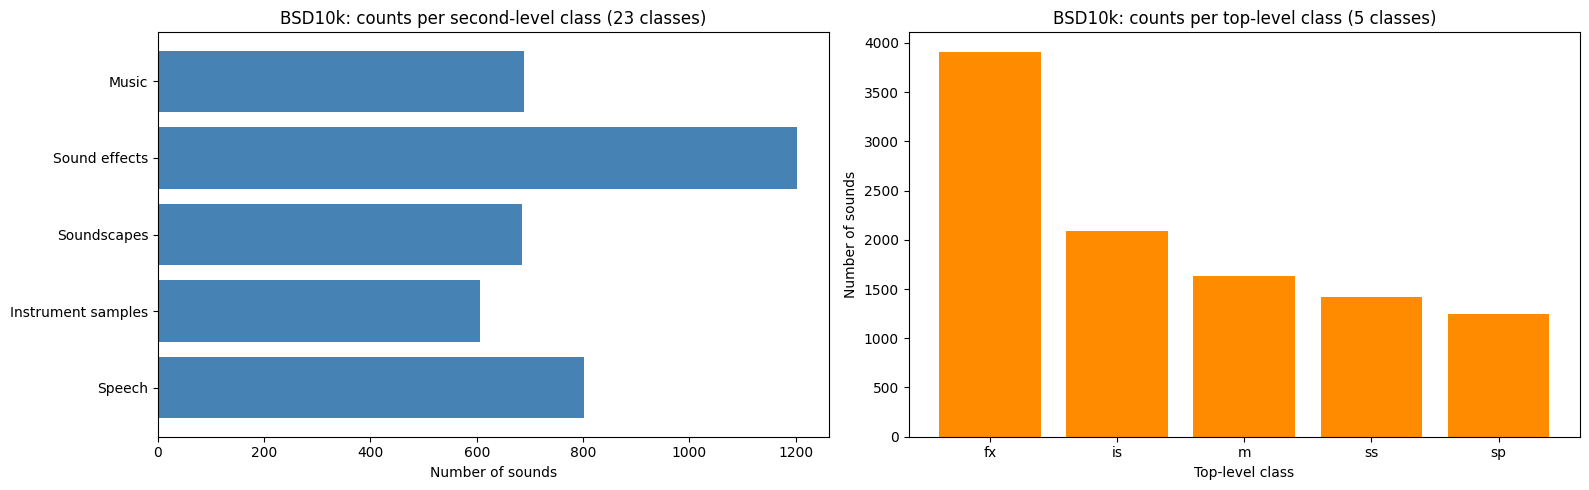

In [6]:
# Quick visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Second-level
counts_sorted = counts.sort_values('count', ascending=True)
axes[0].barh(counts_sorted['class_name'], counts_sorted['count'], color='steelblue')
axes[0].set_xlabel('Number of sounds')
axes[0].set_title('BSD10k: counts per second-level class (23 classes)')

# Top-level
top_counts = metadata_df['class_top'].value_counts()
axes[1].bar(top_counts.index, top_counts.values, color='darkorange')
axes[1].set_xlabel('Top-level class')
axes[1].set_ylabel('Number of sounds')
axes[1].set_title('BSD10k: counts per top-level class (5 classes)')

plt.tight_layout()
plt.show()


## 2 · Subset selection

We keep a **focused subset** of second-level classes for two reasons:
1. Extracting embeddings for all 10k sounds is time-consuming; a subset lets us iterate quickly.
2. A curated set of classes makes the classification results easier to analyse and explain.

**Selection criteria:**
- Perceptual diversity — classes should be acoustically distinct enough to make the problem interesting.
- Sufficient samples — each kept class should have at least ~100 sounds.
- Variety of difficulty — include some pairs that are likely to be confused (e.g. *wind instruments* vs. *soundscapes with wind*).

The 23 second-level classes belong to 5 top-level groups:
`Music`, `Instrument samples`, `Speech`, `Sound effects`, `Soundscapes`.
We pick **at least one class from each top-level group** to preserve diversity.

> **Adjust `SELECTED_CLASSES` below** after running the cells above and inspecting the actual class codes in your download.


In [7]:
# ── Edit this list: use the 'class' codes shown in the distribution table above ─
SELECTED_CLASSES = [
    'm-sp',
    'm-si',
    'm-m',
    'is-s',
    'is-w',
    'is-k',
    'sp-s',
    'sp-c',
    'fx-o',
    'fx-v',
    'fx-a',
    'fx-n',
    'ss-n',
    'ss-i',
    'ss-u',
]
# ─────────────────────────────────────────────────────────────────────────────

# NOTE: the codes above are illustrative — replace them with the real codes
# from `counts` printed in the cell above. BSD10k uses codes like 'mus', 'ins',
# 'spe' etc. (check whether they are upper or lower case in your version).

subset_df = metadata_df[metadata_df['class'].isin(SELECTED_CLASSES)].copy().reset_index(drop=True)

print(f'Subset size: {len(subset_df)} sounds  ({len(SELECTED_CLASSES)} classes)')
print()
display(subset_df.groupby(['class', 'class_name']).size().rename('count'))


Subset size: 7205 sounds  (15 classes)



class  class_name        
fx-a   Sound effects          168
fx-n   Sound effects          659
fx-o   Sound effects         1203
fx-v   Sound effects          199
is-k   Instrument samples     111
is-s   Instrument samples     529
is-w   Instrument samples     552
m-m    Music                  291
m-si   Music                  655
m-sp   Music                  689
sp-c   Speech                  96
sp-s   Speech                 801
ss-i   Soundscapes            178
ss-n   Soundscapes            389
ss-u   Soundscapes            685
Name: count, dtype: int64

In [8]:
# Verify audio files exist for all selected sounds
missing = subset_df[~subset_df['audio_path'].apply(os.path.exists)]
print(f'Missing audio files: {len(missing)}')
if len(missing) > 0:
    print('Sample missing paths:')
    display(missing[['sound_id', 'audio_path']].head(5))


Missing audio files: 0


In [9]:
# Save the subset metadata CSV — this is what notebooks 2 and 3 will load
subset_df.to_csv(SUBSET_CSV, index=False)
print(f'Saved subset metadata → {os.path.abspath(SUBSET_CSV)}')


Saved subset metadata → /home/frederic/Documents/UPF/semester3/advanced/block2_assignment/sound-classification-repo/metadata/subset_metadata.csv


## 4 · Sanity check

In [10]:
methods = ['mfcc', 'fsdsinet', 'clap']

print(f'{'Method':<12}  {'Files saved':>12}  {'Subset size':>12}  {'Shape'}')
print('-' * 55)
for method in methods:
    folder = os.path.join(EMBEDDINGS_FOLDER, method)
    if not os.path.isdir(folder):
        print(f'{method:<12}  (folder not found)')
        continue
    files = [f for f in os.listdir(folder) if f.endswith('.npy')]
    if files:
        example = np.load(os.path.join(folder, files[0]))
        shape_str = str(example.shape)
    else:
        shape_str = 'N/A'
    print(f'{method:<12}  {len(files):>12}  {len(subset_df):>12}  {shape_str}')


Method         Files saved   Subset size  Shape
-------------------------------------------------------
mfcc                 10309          7205  (13,)
fsdsinet             10309          7205  (512,)
clap                 10309          7205  (512,)


## Done!

The subset metadata is at `metadata/subset_metadata.csv`.
Embeddings are under `embeddings/{method}/{sound_id}.npy`.

Continue with:
- **`2_sound_classification.ipynb`** — KNN classification, embedding comparison, misclassification analysis
- **`3_text_audio_retrieval.ipynb`** — CLAP text-to-audio retrieval
